In [1]:
from InterOptimus.itworker import InterfaceWorker
from pymatgen.core.structure import Structure
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

/opt/anaconda3/envs/3.12/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Define InterfaceWorker

In [4]:
film_conv = Structure.from_file('film.cif')
substrate_conv = Structure.from_file('substrate.cif')
iw = InterfaceWorker(film_conv, substrate_conv)

/Users/jason/Downloads/pymatgen-master/src/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


# lattice matching

In [5]:
iw.lattice_matching(max_area = 25, max_length_tol = 0.03, max_angle_tol = 0.03,
                    film_max_miller = 3, substrate_max_miller = 3, film_millers = None, substrate_millers = None)
#Note max millers are in primitive cell, should be different from the indices in the polar projection below which are in conventional cell
#If you specify miller indices yourself, just ignore film_max_miller and substrate_max_miller

5


checking matching identity:   0%|          | 0/5 [00:00<?, ?it/s]

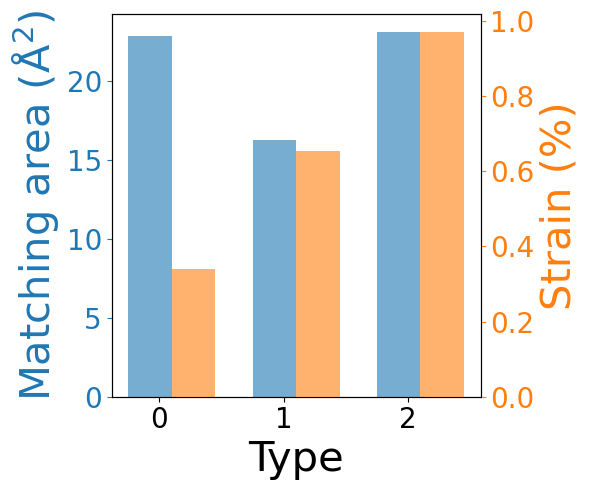

In [6]:
#Visualize matching information
iw.ems.plot_unique_matches()

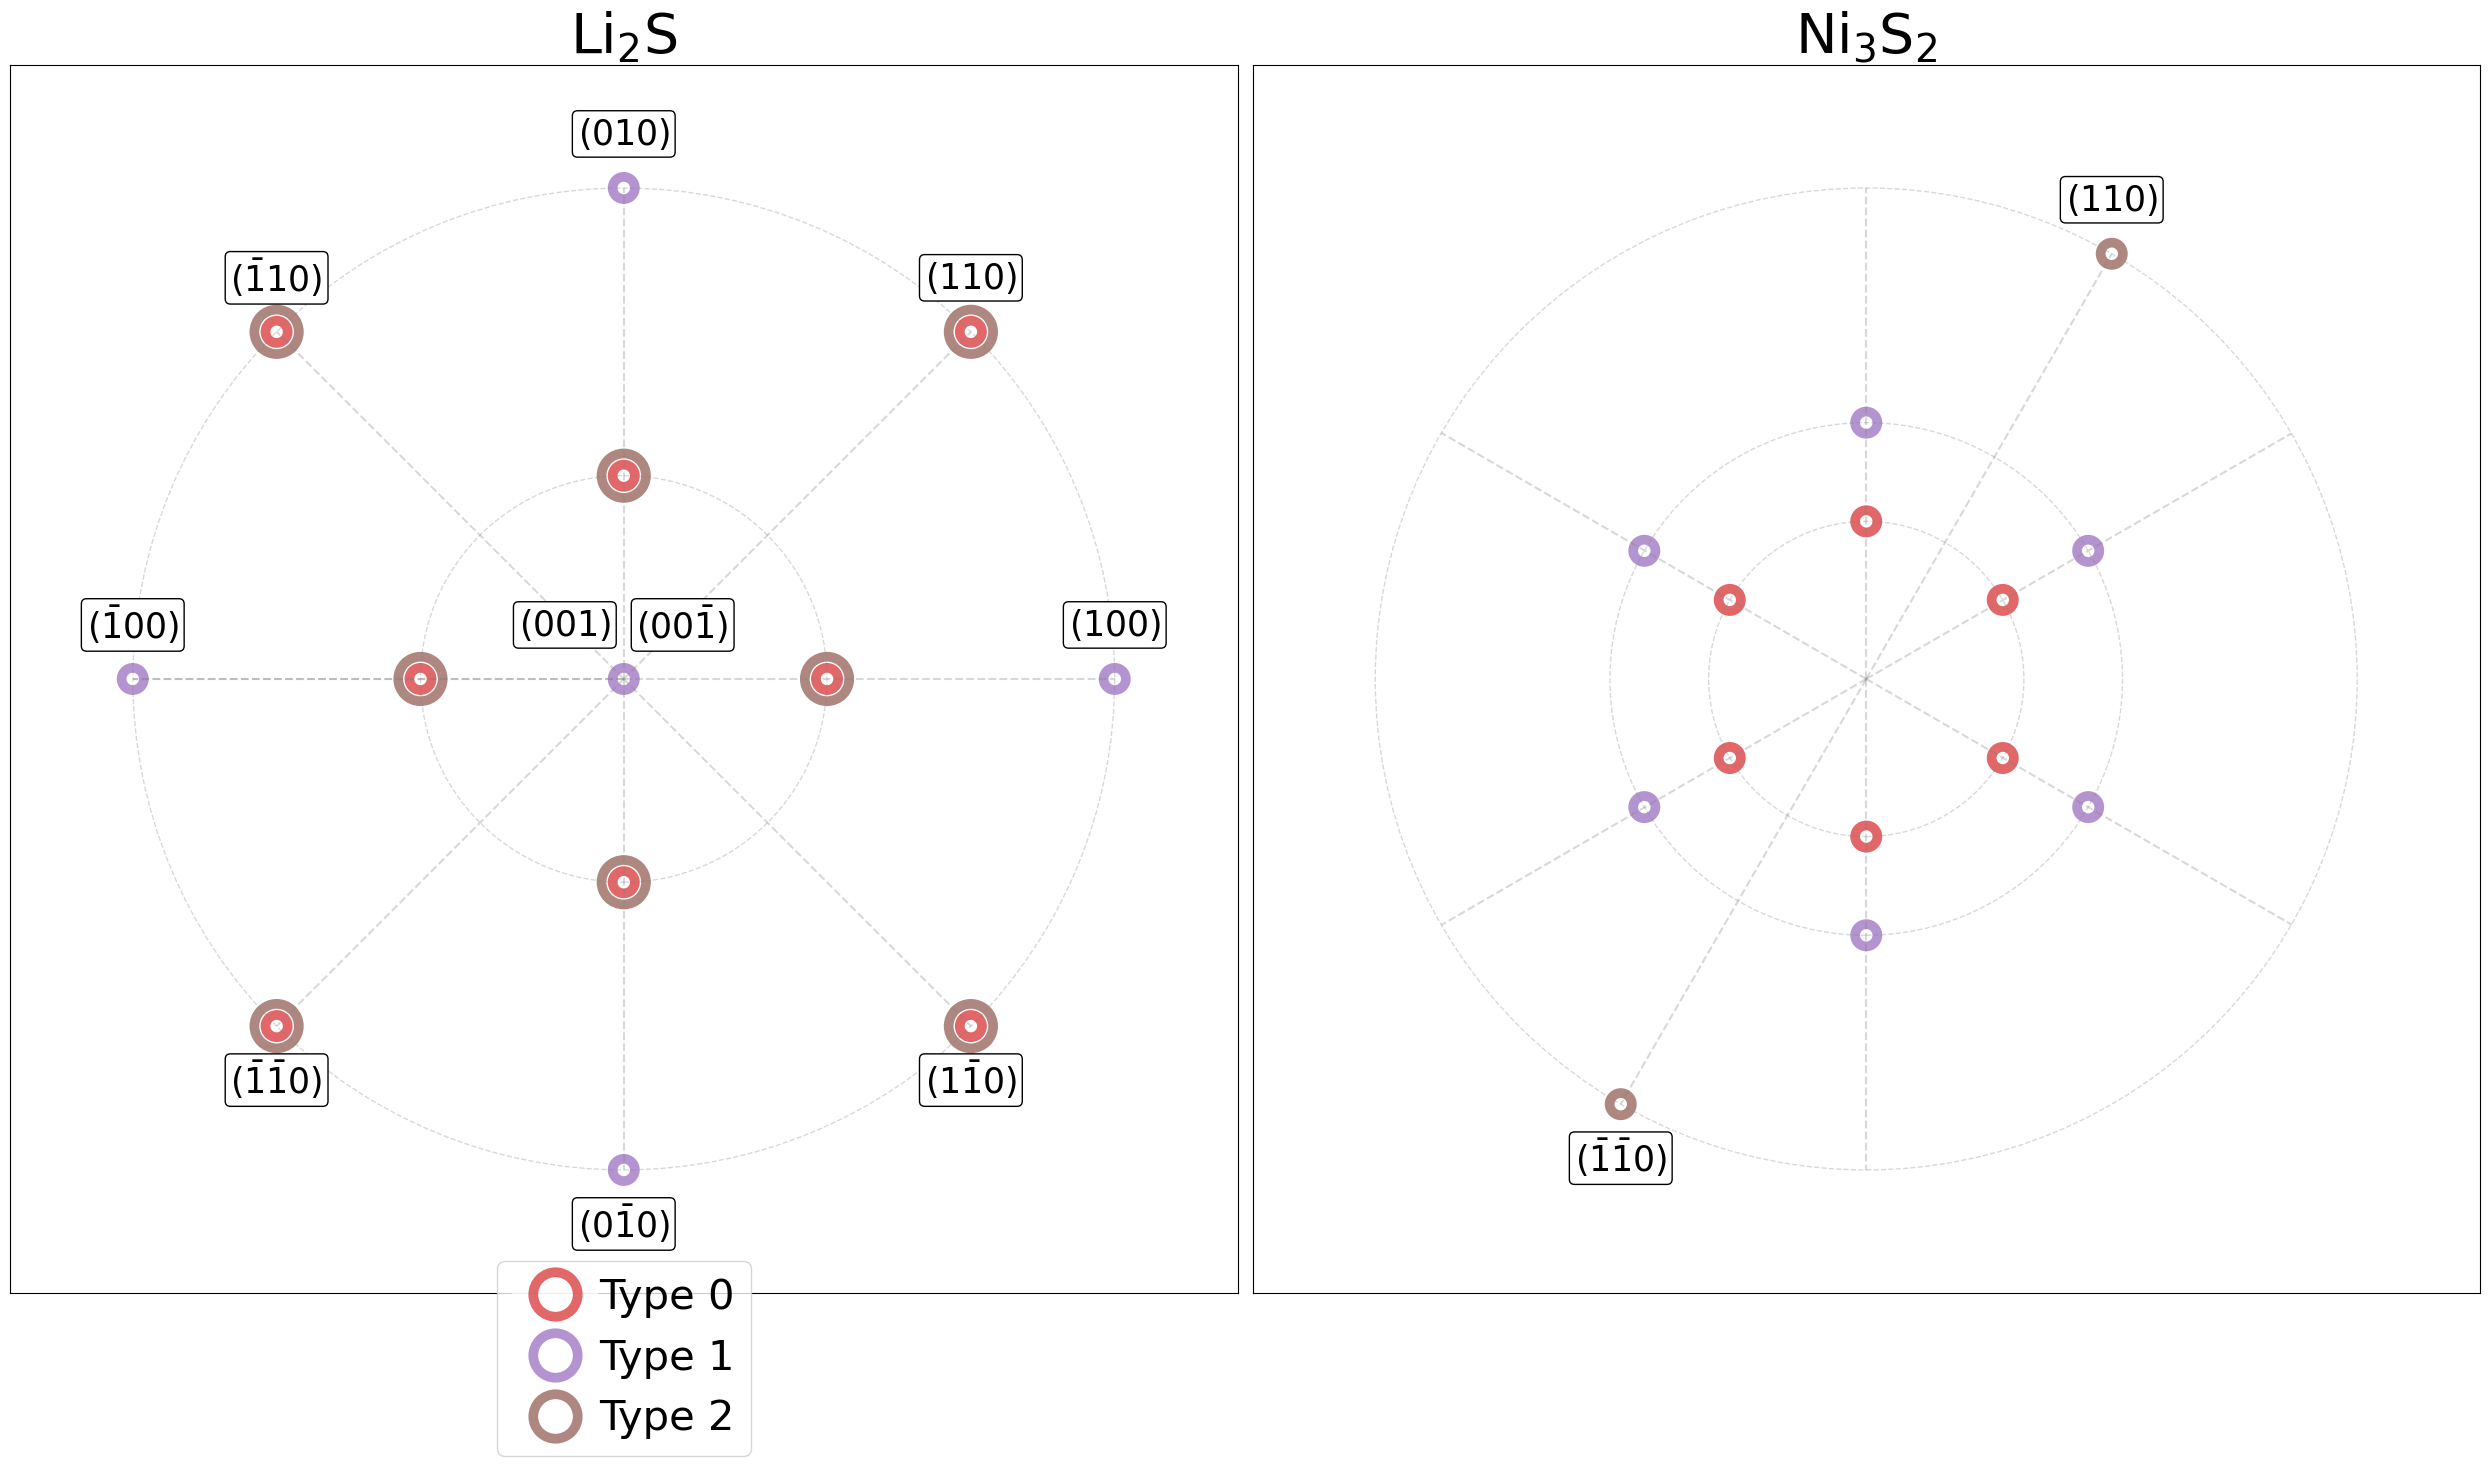

In [7]:
iw.ems.plot_matching_data(['Li$_2$S', 'Ni$_3$S$_2$'],'Ni3S2_Li2S_more.jpg', show_millers = True, show_legend = True)

# Define interface structural parameters 

For usage presentation, a large **termination_ftol** value is applied there.  
However, for some complex systems, a small enough **termination_ftol** (e.g. 0.01) is necessary to find stable interface structures.

In [8]:
#double_interface set to True to exclude vaccum
iw.parse_interface_structure_params(termination_ftol = 0.15, film_thickness = 8, \
                                    substrate_thickness = 8, double_interface= True)



match 0: thicknesses (film, substrate) (2.0, 2.86) (4, 3) (8.02 8.59)
match 1: thicknesses (film, substrate) (2.84, 4.03) (3, 2) (8.51 8.06)
match 2: thicknesses (film, substrate) (2.0, 2.84) (4, 3) (8.02 8.51)
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 0: number of unique terminations: 4
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 1: number of unique terminations: 6
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 2: number of unique terminations: 3


# Baysian Optimization by MLIP for Rigid Body Translation (RBT)

In [7]:
#define structure optimization conditions (optional). If not called, the non-optimized energy and structure will be used
iw.parse_optimization_params(fmax = 0.05, 
                             steps = 200, 
                             device = 'cpu', 
                             discut = 0.8, 
                             ckpt_path = '')

**fmax**: tolerance to stop structure optimization  
**steps**: maximum relaxing steps  
**device**: device to use for MLIP  
**ckpt_path**: path to store the check point, downloading if not set  
**discut**: those with atoyms closer than discut will have energy as 0 (ignore these structures)  

In [8]:
iw.global_minimization(n_calls_density = 1, 
                       z_range = (0.5, 3),
                       calc = 'orb-models', 
                       strain_E_correction = True)

Initializing ORB calculator on device: cpu
Failed to load custom ORB model: [Errno 21] Is a directory: '.'
Using default ORB model


/opt/anaconda3/envs/3.12/lib/python3.12/site-packages/orb_models/utils.py:30: UserWarning: Setting global torch default dtype to torch.float32.
  warnings.warn(f"Setting global torch default dtype to {torch_dtype}.")


matches:   0%|          | 0/3 [00:00<?, ?it/s]

unique terminations:   0%|          | 0/4 [00:00<?, ?it/s]

registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

...

num of selected low-energy its: 1


registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

num of selected low-energy its: 1


registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

num of selected low-energy its: 1
[np.float64(1.5528540142424399), np.float64(1.2387082530156546), np.float64(2.52222261574153)]


**n_calls**: number of bayesian optimization for each RBT optimizatio  
**z_range**: range of z coordinates for RBT optimization  
**calc**: energy calculator (only for orb-models and sevenn)  
**strain_E_correction**: whether the binding energy or interface energy is corrected considering film elastic energy by strain

In [11]:
iw.global_optimized_data

,$h_f$,$k_f$,$l_f$,$h_s$,$k_s$,$l_s$,$A$ (Å$^2$),$\epsilon$,$E_{it}$ $(J/m^2)$,$E_{el}$ $(eV/atom)$,...,$w_{f2}$,$u_{s1}$,$v_{s1}$,$w_{s1}$,$u_{s2}$,$v_{s2}$,$w_{s2}$,$T$,$i_m$,$i_t$
0,-1,0,1,1,-1,2,22.870982,0.003387,0.889633,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 1_Ni_Pmmm_1)",0,0
10,-1,0,1,1,1,0,23.086703,0.009700,0.967135,0.000031,...,0,-1/3,1/3,1/3,1/3,-1/3,2/3,"(1_Li2S_Pmmm_3, 1_S_Pmma_2)",2,0
3,-1,0,1,1,-1,2,22.870982,0.003387,1.009197,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 4_Ni_Pmmm_1)",0,3
11,-1,0,1,1,1,0,23.086703,0.009700,1.077775,0.000031,...,0,-1/3,1/3,1/3,1/3,-1/3,2/3,"(1_Li2S_Pmmm_3, 2_Ni_Pmmm_1)",2,1
7,-1,0,0,1,0,1,16.248674,0.006540,1.121156,-0.000238,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(2_Li_P4/mmm_2, 1_NiS_Pmm2_2)",1,3
4,-1,0,0,1,0,1,16.248674,0.006540,1.126625,-0.000238,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(1_S_P4/mmm_1, 1_NiS_Pmm2_2)",1,0
8,-1,0,0,1,0,1,16.248674,0.006540,1.170017,-0.000238,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(2_Li_P4/mmm_2, 2_NiS_Pmm2_2)",1,4
6,-1,0,0,1,0,1,16.248674,0.006540,1.185442,-0.000238,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(1_S_P4/mmm_1, 3_Ni_P4/mmm_1)",1,2
2,-1,0,1,1,-1,2,22.870982,0.003387,1.503482,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 3_S_Pmmn_2)",0,2
1,-1,0,1,1,-1,2,22.870982,0.003387,1.559280,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 2_Ni_Pmmm_1)",0,1


/Users/jason/Documents/GitHub/InterOptimus/InterOptimus/matching.py:1595: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1], pad=0.1)


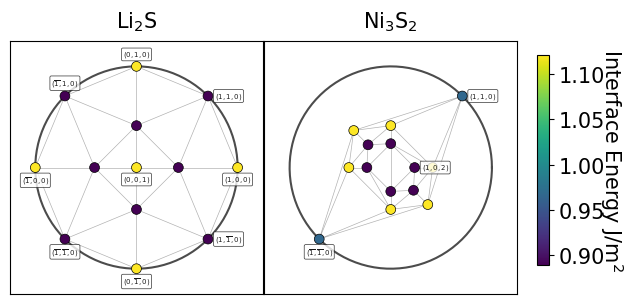

In [12]:
iw.visualize_minimization_results(film_name = 'Li$_2$S', substrate_name = 'Ni$_3$S$_2$')

# lowest energy interface for each match

In [14]:
pairs = iw.get_lowest_energy_pairs_each_match(only_lowest_energy_each_plane=True)